<a href="https://colab.research.google.com/github/raginips/Sale_Predictions_Project_Housing_GenAI_RaginiPS/blob/main/NLP_Amazon_Review_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Amazon Review Processing** , by Ragini PS

# **Data Loading and Exploration:**

In [6]:
# 1. Load the dataset (adjust path if needed)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/content/7817_1.csv")

In [8]:
# 2. Explore data properties
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [9]:
df.shape

(1597, 27)

In [10]:
df.dtypes

,0
id,object
asins,object
brand,object
categories,object
colors,object
dateAdded,object
dateUpdated,object
dimension,object
ean,float64
keys,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [12]:
df.describe()

,ean,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince,sizes,upc
count,8.980000e+02,900.000000,1177.000000,0.0,0.0,0.0,8.980000e+02
mean,8.443135e+11,83.584444,4.359388,NaN,NaN,NaN,8.443135e+11
std,3.416444e+09,197.150238,1.021445,NaN,NaN,NaN,3.416444e+09
min,8.416670e+11,0.000000,1.000000,NaN,NaN,NaN,8.416670e+11
25%,8.416670e+11,0.000000,4.000000,NaN,NaN,NaN,8.416670e+11
50%,8.416670e+11,0.000000,5.000000,NaN,NaN,NaN,8.416670e+11
75%,8.487190e+11,34.000000,5.000000,NaN,NaN,NaN,8.487190e+11
max,8.487190e+11,997.000000,5.000000,NaN,NaN,NaN,8.487190e+11


In [13]:
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,823
dateAdded,0
dateUpdated,0
dimension,1032
ean,699
keys,0


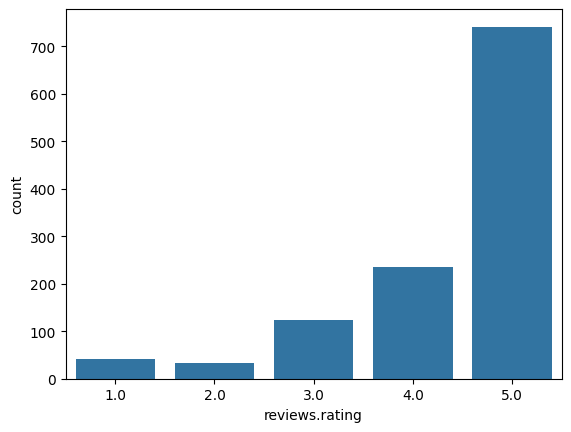

In [14]:
# 3. Analyze rating distribution
sns.countplot(x=df['reviews.rating'])
plt.show()

In [15]:
df = df[['reviews.rating','reviews.text']]
df.head()

,reviews.rating,reviews.text
0,5.0,I initially had trouble deciding between the p...
1,5.0,Allow me to preface this with a little history...
2,4.0,I am enjoying it so far. Great for reading. Ha...
3,5.0,I bought one of the first Paperwhites and have...
4,5.0,I have to say upfront - I don't like coroporat...


In [16]:
df = df.dropna(subset=['reviews.rating','reviews.text'])
df.head(5)
df.isnull().sum()

,0
reviews.rating,0
reviews.text,0


In [17]:
df['reviews.rating'] = df['reviews.rating'].astype(int)
df.head(5)

,reviews.rating,reviews.text
0,5,I initially had trouble deciding between the p...
1,5,Allow me to preface this with a little history...
2,4,I am enjoying it so far. Great for reading. Ha...
3,5,I bought one of the first Paperwhites and have...
4,5,I have to say upfront - I don't like coroporat...


In [18]:
# Map ratings to sentiment categories
def get_sentiments(rating):
  if rating == 5:
    return 'positive'
  elif rating == 4:
    return 'positive'
  elif rating == 3:
    return 'neutral'
  elif rating == 2:
    return 'negative'
  elif rating == 1:
    return 'negative'

df['sentiment'] = df['reviews.rating'].apply(get_sentiments)
print(df['sentiment'].value_counts())

sentiment
positive    977
neutral     124
negative     76
Name: count, dtype: int64


In [19]:
df.head()

,reviews.rating,reviews.text,sentiment
0,5,I initially had trouble deciding between the p...,positive
1,5,Allow me to preface this with a little history...,positive
2,4,I am enjoying it so far. Great for reading. Ha...,positive
3,5,I bought one of the first Paperwhites and have...,positive
4,5,I have to say upfront - I don't like coroporat...,positive


# **Text Cleaning and Preprocessing:**

In [22]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab') # Added to download the missing resource

# Initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # a. Remove HTML tags & punctuation/special characters
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # b. Convert to lowercase
    text = text.lower()
    # c. Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords & d. Lemmatize to root form;p
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(cleaned_tokens)

# Apply cleaning to the dataset
df['cleaned_text'] = df['reviews.text'].apply(clean_text)
# Calculate review length for later tasks
df['review_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df.head(5)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,reviews.rating,reviews.text,sentiment,cleaned_text,review_length
0,5,I initially had trouble deciding between the p...,positive,initially trouble deciding paperwhite voyage r...,92
1,5,Allow me to preface this with a little history...,positive,allow preface little history casual reader own...,125
2,4,I am enjoying it so far. Great for reading. Ha...,positive,enjoying far great reading original fire since...,18
3,5,I bought one of the first Paperwhites and have...,positive,bought one first paperwhites pleased constant ...,153
4,5,I have to say upfront - I don't like coroporat...,positive,say upfront dont like coroporate hermetically ...,183


# **Exploratory Analysis:**

In [24]:
from collections import Counter

# 1. Most frequent words
all_words = " ".join(df['cleaned_text']).split()
word_counts = Counter(all_words)
most_common_words = word_counts.most_common(10)
print("Top 10 most frequent words:", most_common_words)

Top 10 most frequent words: [('amazon', 822), ('fire', 772), ('like', 744), ('kindle', 729), ('great', 586), ('sound', 574), ('use', 564), ('one', 563), ('tablet', 538), ('device', 511)]


In [25]:
# Correlation between review length and ratings
correlation = df['review_length'].corr(df['reviews.rating'])
print("Correlation between review length and ratings:", correlation)

Correlation between review length and ratings: 0.0012978500705465442


# **Text Visualization:**

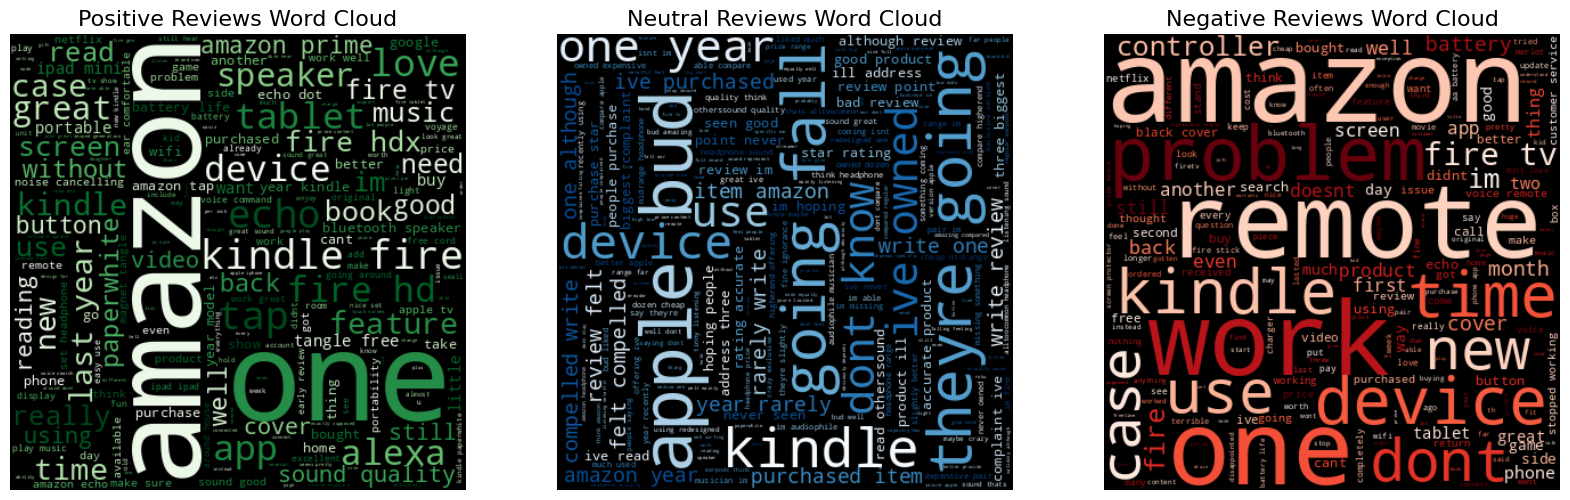

In [28]:
from wordcloud import WordCloud

# 1. Word Clouds by Sentiment
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors = ['Greens', 'Blues', 'Reds']

for i, sent in enumerate(['positive', 'neutral', 'negative']): # Changed to lowercase sentiments
    text_subset = " ".join(df[df['sentiment'] == sent]['cleaned_text'])
    wc = WordCloud(width=400, height=400, background_color='black', colormap=colors[i]).generate(text_subset)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{sent.capitalize()} Reviews Word Cloud', fontsize=16) # Capitalize for display
    axes[i].axis('off')
plt.show()

/tmp/ipykernel_6635/3415414886.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=['positive', 'neutral', 'negative'], palette='Set2')


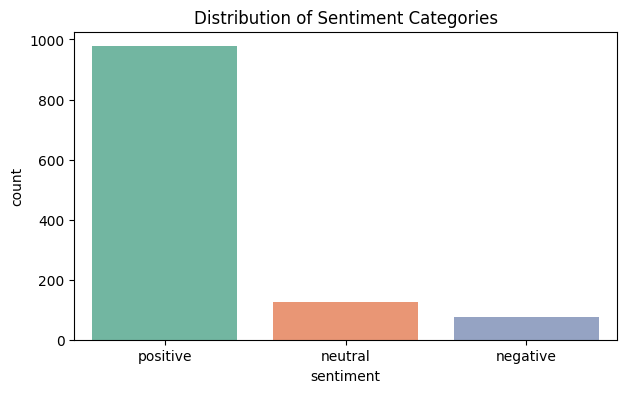

In [29]:
# 2. Bar plot of sentiment categories
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='sentiment', order=['positive', 'neutral', 'negative'], palette='Set2')
plt.title('Distribution of Sentiment Categories')
plt.show()

/tmp/ipykernel_6635/2130155028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='reviews.rating', y='review_length', palette='magma')


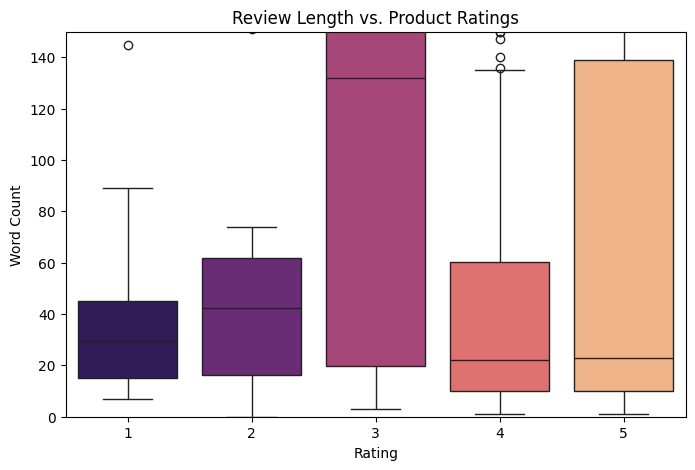

In [30]:
# 3. Box plot: Review length vs Ratings
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='reviews.rating', y='review_length', palette='magma')
plt.title('Review Length vs. Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.ylim(0, 150) # Limit y-axis to see the boxes clearly if outliers exist
plt.show()

# **Advanced Analysis:**

In [31]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans

# Prepare Vectorizer for Topic Modeling and Clustering
vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = vectorizer.fit_transform(df['cleaned_text'])

# 1. Topic Modeling (LDA)
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(tfidf_matrix)

print("--- Extracted Topics (LDA) ---")
words = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[:-6:-1]]
    print(f"Topic #{topic_idx + 1}: {', '.join(top_words)}")


--- Extracted Topics (LDA) ---
Topic #1: headphone, like, apple, im, dont
Topic #2: great, tap, speaker, echo, love
Topic #3: gift, prime, tv, recommend, great


In [32]:
# 2. Clustering (K-Means)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(tfidf_matrix)
print("\nReview distribution across clusters:")
print(df['cluster'].value_counts())



Review distribution across clusters:
cluster
0    731
1    369
2     77
Name: count, dtype: int64


In [33]:
# 3. Word Co-occurrence Matrix (Top 10 words)
cv = CountVectorizer(vocabulary=[w for w, c in word_counts.most_common(10)])
co_occurrence_matrix = cv.fit_transform(df['cleaned_text'])
matrix_df = (co_occurrence_matrix.T * co_occurrence_matrix)
matrix_df.setdiag(0) # Remove self-co-occurrence

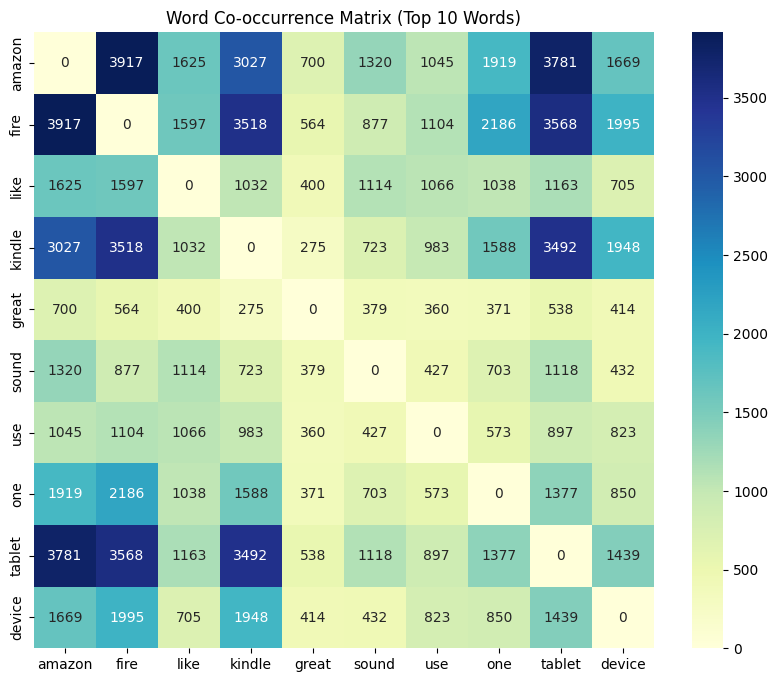

In [34]:
plt.figure(figsize=(10, 8))
sns.heatmap(matrix_df.todense(), annot=True, fmt='d', xticklabels=cv.get_feature_names_out(), yticklabels=cv.get_feature_names_out(), cmap='YlGnBu')
plt.title('Word Co-occurrence Matrix (Top 10 Words)')
plt.show()